In this tutorial we will show how to solve an acoustic transmission problem in
the context of Helmholtz equation in two dimensions.

In [1]:
using Inti

k₁ = 8π
k₂ = 2π
λ₁ = 2π / k₁
λ₂ = 2π / k₂
meshsize   = min(λ₁,λ₂) / 10
qorder     = 4 # quadrature order
gorder     = 2 # order of geometrical approximation
nothing #hide

using Gmsh # this will trigger the loading of Inti's Gmsh extension

function gmsh_circle(; name, meshsize, order = 1, radius = 1, center = (0, 0))
    try
        gmsh.initialize()
        gmsh.model.add("circle-mesh")
        gmsh.option.setNumber("Mesh.MeshSizeMax", meshsize)
        gmsh.option.setNumber("Mesh.MeshSizeMin", meshsize)
        gmsh.model.occ.addDisk(center[1], center[2], 0, radius, radius)
        gmsh.model.occ.synchronize()
        gmsh.model.mesh.generate(1)
        gmsh.model.mesh.setOrder(order)
        gmsh.write(name)
    finally
        gmsh.finalize()
    end
end


name = joinpath(@__DIR__, "circle.msh")
gmsh_circle(; meshsize, order = gorder, name)
Ω, msh = Inti.import_mesh_from_gmsh_file(name; dim = 2)

Γ = Inti.boundary(Ω)
Γ_msh = view(msh,Γ)

Q = Inti.Quadrature(Γ_msh; qorder)

pde₁ = Inti.Helmholtz(; k=k₁, dim = 2)
pde₂ = Inti.Helmholtz(; k=k₂, dim = 2)

using FMMLIB2D
S₁, D₁ = Inti.single_double_layer(;
    pde=pde₁,
    target = Q,
    source = Q,
    compression = (method = :fmm,tol=:1e-8),
    correction = (method = :dim, maxdist = 5 * meshsize),
)

K₁, N₁ = Inti.adj_double_layer_hypersingular(;
    pde=pde₁,
    target = Q,
    source = Q,
    compression = (method = :fmm,tol=:1e-8),
    correction = (method = :dim, maxdist = 5 * meshsize),
)

S₂, D₂ = Inti.single_double_layer(;
    pde=pde₂,
    target = Q,
    source = Q,
    compression = (method = :fmm,tol=:1e-8),
    correction = (method = :dim, maxdist = 5 * meshsize),
)

K₂, N₂ = Inti.adj_double_layer_hypersingular(;
    pde=pde₂,
    target = Q,
    source = Q,
    compression = (method = :fmm,tol=:1e-8),
    correction = (method = :dim, maxdist = 5 * meshsize),
)

using LinearAlgebra
using LinearMaps

L =[I+LinearMap(D₁)-LinearMap(D₂) -LinearMap(S₁)+LinearMap(S₂);LinearMap(N₁)-LinearMap(N₂) I-LinearMap(K₁)+LinearMap(K₂)]

θ = π/4; 𝐝 = [cos(θ),sin(θ)]
u₂ = x -> exp(im * k₂ * dot(x,𝐝)) # plane-wave incident field
∇u₂ = x -> im*k₂*u₂(x)*𝐝     # gradient of incident field

using SpecialFunctions
u₁ = x -> hankelh1(0,k₁*sqrt(dot(x,x))) # point source in the interior of the circle
∇u₁ = x -> -k₁*hankelh1(1,k₁*sqrt(dot(x,x)))*x/sqrt(dot(x,x))     # gradient of the point source field

rhs₁ = map(Q) do q
    x = q.coords
    return u₁(x)+u₂(x)
end

rhs₂ = map(Q) do q
    x = q.coords
    n = q.normal
    return dot(n,∇u₁(x)+∇u₂(x))
end

rhs = [rhs₁;rhs₂]

using IterativeSolvers
sol, hist =
    gmres(L, rhs; log = true, abstol = 1e-6, verbose = false, restart = 400, maxiter = 400)
@show hist

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.000303811s, CPU 0.000286s)
Info    : 252 nodes 253 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 50%] Meshing surface 1 order 2
Info    : Done meshing order 2 (Wall 0.00245215s, CPU 0.00245s)
Info    : Writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'...
Info    : Done writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'
Info    : Reading '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'...
Info    : 3 entities
Info    : 504 nodes
Info    : 253 elements
Info    : Done reading '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'
┌ Warning: overwriting an existing entity with the same (dim,tag)=(0,1)
└ @ Inti ~/runner-in

Converged after 46 iterations.

sol = L \ rhs

In [2]:
nQ = size(Q,1)
sol = reshape(sol,nQ,2)
φ,ψ = sol[:,1],sol[:,2]


𝒮₁, 𝒟₁ = Inti.single_double_layer_potential(; pde=pde₁, source = Q)
𝒮₂, 𝒟₂ = Inti.single_double_layer_potential(; pde=pde₂, source = Q)

v₁  = x ->  𝒟₁[φ](x) - 𝒮₁[ψ](x)
v₂  = x -> -𝒟₂[φ](x) + 𝒮₂[ψ](x)

#16 (generic function with 1 method)

Here is the maximum error on some points located on a circle of radius `2`:

In [3]:
er₁ = maximum(0:0.01:2π) do θ
    R = 2.0
    x = (R * cos(θ), R * sin(θ))
    xp = [R * cos(θ), R * sin(θ)]
    return abs(v₁(x) - u₁(xp))
end
@assert er₁ < 1e-3 #hide
@info "maximum error = $er₁"

[ Info: maximum error = 2.105411760835214e-8


Here is the maximum error on some points located on a circle of radius `0.5`:

[ Info: maximum error = 3.793393338015632e-9


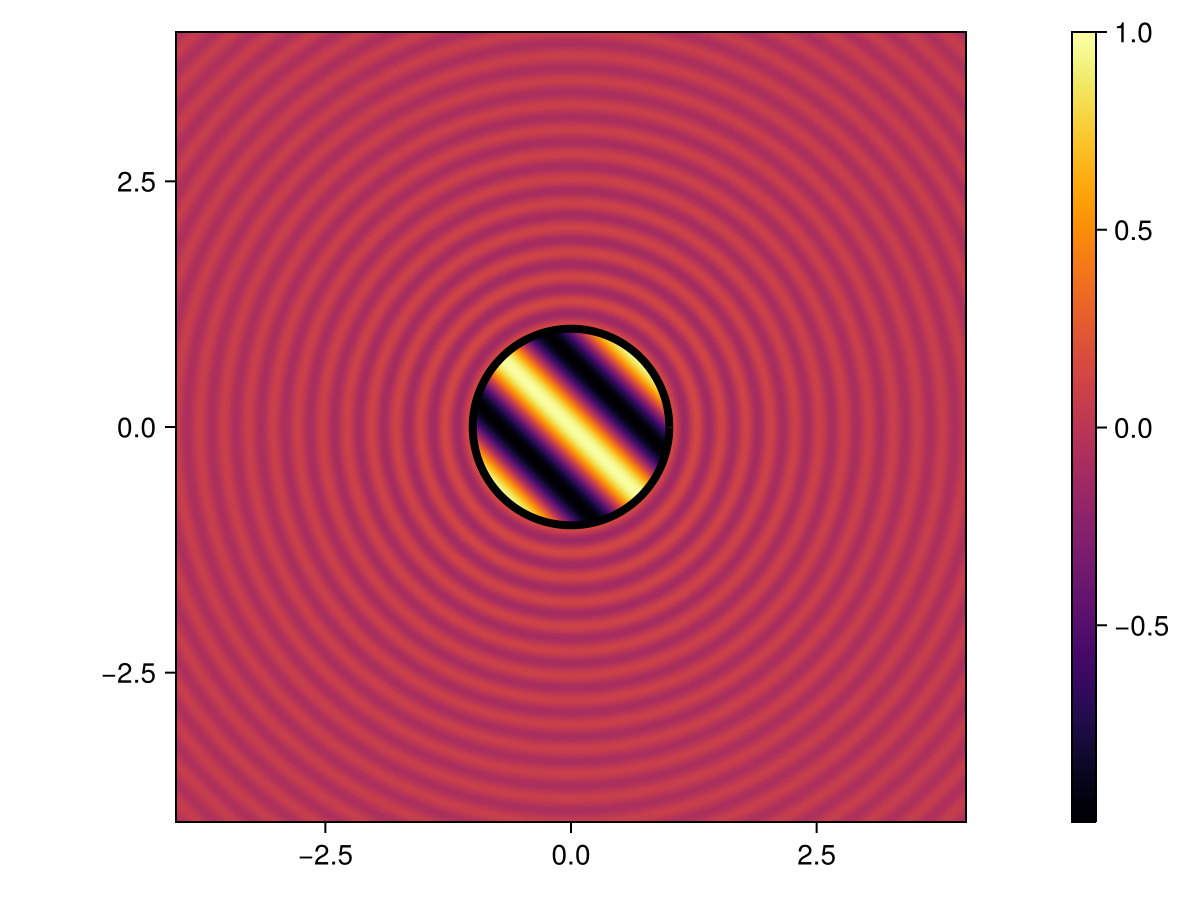

In [4]:
er₂ = maximum(0:0.01:2π) do θ
    R = 0.5
    x = (R * cos(θ), R * sin(θ))
    xp = [R * cos(θ), R * sin(θ)]
    return abs(v₂(x) - u₂(xp))
end
@assert er₂ < 1e-3 #hide
@info "maximum error = $er₂"



using CairoMakie
xx = yy = range(-4; stop = 4, length = 200)
vals = map(pt -> norm(pt) > 1 ? real(u₁(pt)) : real(u₂(pt)), Iterators.product(xx, yy))
fig, ax, hm = heatmap(
    xx,
    yy,
    vals;
    colormap = :inferno,
    interpolate = true,
    axis = (aspect = DataAspect(), xgridvisible = false, ygridvisible = false),
)
lines!(
    ax,
    [cos(θ) for θ in 0:0.01:2π],
    [sin(θ) for θ in 0:0.01:2π];
    color = :black,
    linewidth = 4,
)
Colorbar(fig[1, 2], hm)
fig

function gmsh_kite(; radius = 1, center = (0,0,0), npts = ceil(Int,radius*10))
    f = (s) -> center .+ radius .* (cospi(2 * s[1]) + 0.65 * cospi(4 * s[1]) - 0.65,
            1.5 * sinpi(2 * s[1]))
    pt_tags = Int32[]
    for i in 0:npts-1
        s = i / npts
        x = center[1] + radius * (cospi(2 * s[1]) + 0.65 * cospi(4 * s[1]) - 0.65)
        y = center[2] + radius * (1.5 * sinpi(2 * s[1]))
        z = 0
        t = gmsh.model.occ.addPoint(x,y,z)
        push!(pt_tags,t)
    end
    # close the curve by adding the first point again
    push!(pt_tags,pt_tags[1])
    gmsh.model.occ.addSpline(pt_tags, 1000)
    gmsh.model.occ.synchronize()
end

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*